In [1]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch
    from matplotlib.patches import Circle
except:
    %pip install mplsoccer
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch  
    from matplotlib.patches import Circle  

In [2]:
eventsMessi = pd.read_csv('eventsMessi.csv')

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_17772\1308467389.py:1: DtypeWarning: Columns (1,4,5,6,7,10,12,13,14,16,17,18,19,28,40,42,44,46,49,50,64,65,66,67,68,69,70,71,73,74,75,76,83,84,85,86,88,89,90,91,92,93,97,98,99,100,101,102,103,104,105,106,107,113) have mixed types. Specify dtype option on import or set low_memory=False.
  eventsMessi = pd.read_csv('eventsMessi.csv')


In [3]:
eventsMessi

,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,...,player_off_permanent,goalkeeper_success_out,half_end_early_video_end,goalkeeper_saved_to_post,x_start,y_start,x_end,y_end,x_carry_end,y_carry_end
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,49.1,56.9,45.5,55.3,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,61.9,34.5,77.7,67.2,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,79.7,59.7,65.1,60.9,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,77.7,58.1,94.0,45.6,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,92.0,49.6,112.4,37.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,97.9,63.3,NaN,NaN,NaN,NaN
115197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,31.7,15.0,NaN,NaN,NaN,NaN
115198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,86.8,19.6,NaN,NaN,NaN,NaN
115199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,81.8,22.2,NaN,NaN,NaN,NaN


In [4]:
seasons = sorted(eventsMessi['season'].unique().tolist())

In [5]:
col = eventsMessi.columns.tolist()

initialYears = pd.DataFrame(columns=col)
pepYears = pd.DataFrame(columns=col)
msnYears = pd.DataFrame(columns=col)
swanSong = pd.DataFrame(columns=col)

dfList = []

for season in seasons:
    if(season=='2004/2005' or season=='2005/2006'
       or season=='2006/2007' or season=='2007/2008'):
        initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2008/2009' or season=='2009/2010'
       or season=='2010/2011' or season=='2011/2012' or season=='2012/2013'):
        pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2013/2014'or season=='2014/2015'
         or season=='2015/2016'or season=='2016/2017'):
        msnYears = pd.concat([msnYears,eventsMessi[eventsMessi['season']==season]])
    
    else:
        swanSong = pd.concat([swanSong,eventsMessi[eventsMessi['season']==season]]) 
    

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_17772\668474633.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_17772\668474633.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_17772\668474633.py:21: FutureWarning: The behavior of DataFra

In [6]:
def kdePlot(df):
    x = df['x_start']
    y = df['y_start']
    
    pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
    fig, ax = pitch.draw()
    fig.set_facecolor('#a50044')
    
    kdeplot = pitch.kdeplot(x, y,fill=True,n_levels=200,cmap='gnuplot', ax=ax)
    

In [7]:
def heatmap(df,type):
    
    if(type=="pass"):
        pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)
    elif(type=="all"):
        pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
    else:
        pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
    
    fig, ax = pitch.draw()
    
    fig.set_facecolor('#a50044')
    
    x = df["x_start"]
    y = df["y_start"]
    
    if(type=="carryEnd"):
        x = df["x_carry_end"]
        y = df["y_carry_end"]
    
    
    bin_statistic = pitch.bin_statistic(x, y, statistic='count', bins=(6, 5), normalize=True)
    pitch.heatmap(bin_statistic, ax=ax, cmap='hot', edgecolor='#f9f9f9',alpha=0.7)
    labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                                ax=ax, ha='center', va='center',
                                str_format='{:.0%}')
        
        

In [8]:
def drib(dfSuc,dfNut,dfUnSuc):
    pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')

    fig, axs = pitch.draw()

    fig.set_facecolor('#a50044')  
    
    sDribbles = pitch.scatter(dfSuc['x_start'], dfSuc['y_start'],
                   marker='*',
                   c='#00dd98',
                   ax=axs)

    nDribbles = pitch.scatter(dfNut['x_start'], dfNut['y_start'],
                    marker='h',
                    c='#ebddee',
                    ax=axs)

    uDribbles = pitch.scatter(dfUnSuc['x_start'], dfUnSuc['y_start'],
                    marker='x',
                    c='#AA5500',
                    ax=axs)

In [9]:
def hexbin(df):
    pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
    fig, axs = pitch.draw(nrows=1, ncols=2,figsize=(15, 7))

    fig.set_facecolor('#a50044')
    psHexbin = pitch.hexbin(df['x_start'], df['y_start'], ax=axs[0], edgecolors='#f4f4f4',
                        alpha=0.7, gridsize=(10,4), cmap='hot')
    peHexbin = pitch.hexbin(df['x_end'], df['y_end'], ax=axs[1], edgecolors='#f4f4f4',
                        alpha=0.7, gridsize=(10,4), cmap='hot')

    cbar1 = fig.colorbar(psHexbin, ax=axs[0], shrink=0.6,label='count')
    cbar2 = fig.colorbar(peHexbin, ax=axs[1], shrink=0.6,label='count')

In [10]:
def scatter(df,type):
    pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

    fig, axs = pitch.draw(figsize=(8,6))

    fig.set_facecolor('#a50044')
    
    if(type=="assists"):
        sAssists = pitch.scatter(df['x_start'], df['y_start'],
                   marker='*',
                   c='#00dd98',
                   ax=axs)
    else:
        iyGoalsPlot = pitch.scatter(df['x_start'], df['y_start'],
                   marker='*',
                   c=df['shot_statsbomb_xg'],
                   s=(df['shot_statsbomb_xg']*900) + 100,
                   ax=axs)

        cbar = fig.colorbar(iyGoalsPlot, ax=axs, shrink=0.6,label='xG')

In [11]:
circH = Circle((120.0, 40.0), radius = 15,color='red')
circV = Circle((40.0, 120.0), radius = 15,color='red')

In [12]:
def dangerPass(df):

    DangerPass = [row['id'] for index,row in df.iterrows()
                  if ((circH.contains_point([row['x_end'],row['y_end']])==True)
                      or (circV.contains_point([row['x_end'],row['y_end']])==True))]

    DangerPasses = df[df['id'].isin(DangerPass)]

    heatmap(DangerPasses,"pass")

In [13]:
setpiece = ["Corner", "Throw-in","Free Kick", "Penalty"]

## Breakthrough

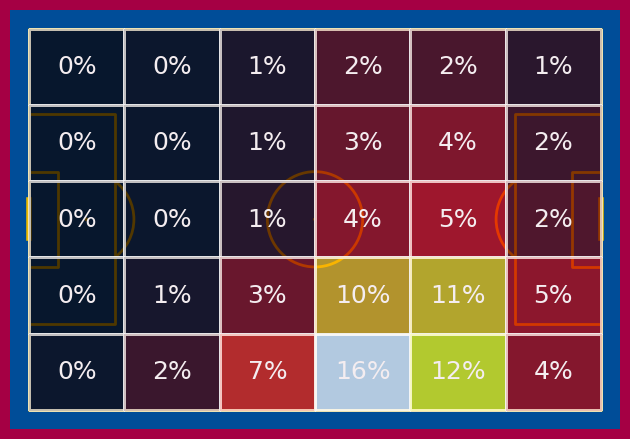

In [14]:
heatmap(initialYears,"all")

### Movement

In [15]:
iyCarry = initialYears[initialYears['type']=='Carry']

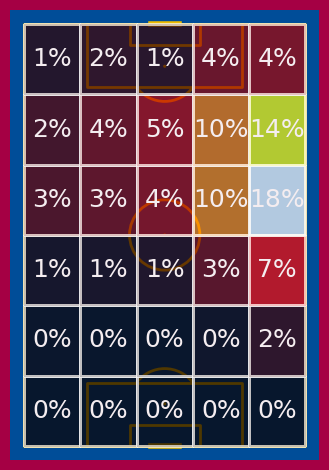

In [16]:
heatmap(iyCarry,"start")

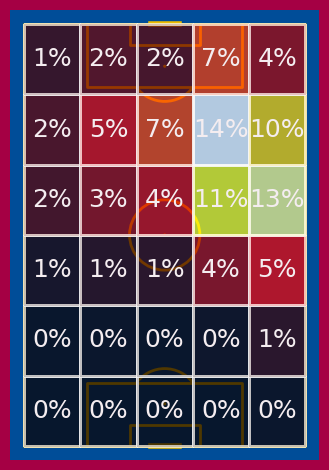

In [17]:
heatmap(iyCarry,"carryEnd")

In [18]:
iyDribbles = initialYears[initialYears['type']=="Dribble"]
iyASDribbles = iyDribbles[iyDribbles['dribble_outcome']=='Complete']
iyNDribbles = iyASDribbles[iyASDribbles['dribble_nutmeg']==True]
iySDribbles = iyASDribbles[iyASDribbles['dribble_nutmeg'].isna()]
iyUDribbles = iyDribbles[iyDribbles['dribble_outcome']=='Incomplete']

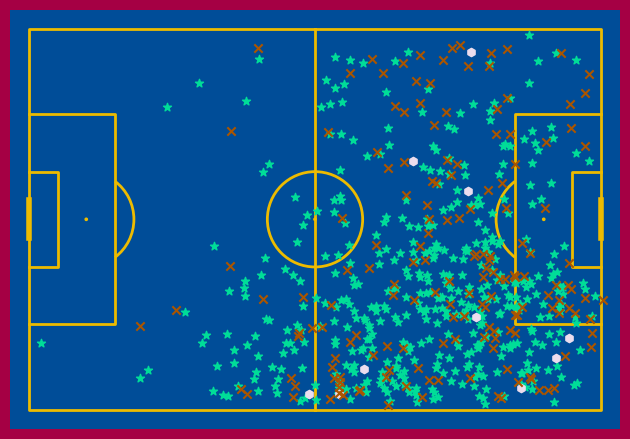

In [19]:
drib(iySDribbles,iyNDribbles,iyUDribbles)

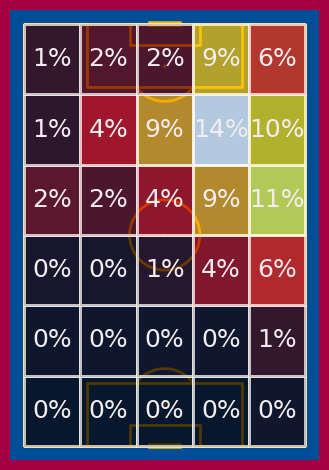

In [20]:
heatmap(iyASDribbles,"dribble")

### Passing

In [21]:
passesIY = initialYears[initialYears['type']=='Pass']
sPIY = passesIY[passesIY['pass_outcome'].isna()]

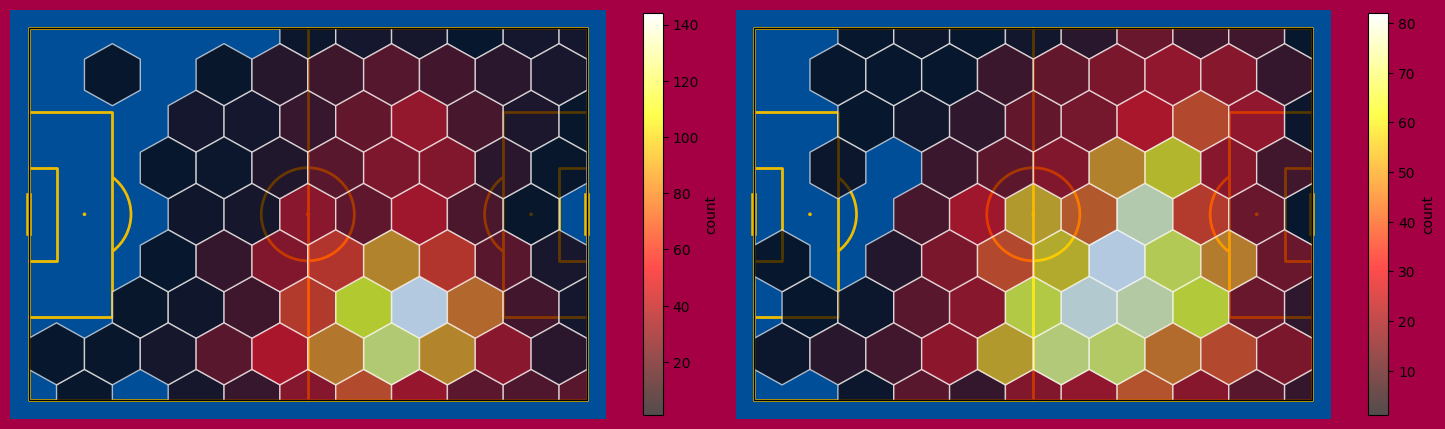

In [22]:
hexbin(sPIY)

In [23]:
topRecip = sPIY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)
topRecip

,player_name,counts
0,Xavier Hernández Creus,354
1,Anderson Luís de Souza,297
2,Ronaldo de Assis Moreira,284
3,Andrés Iniesta Luján,160
4,Samuel Eto''o Fils,157


### Playmaking

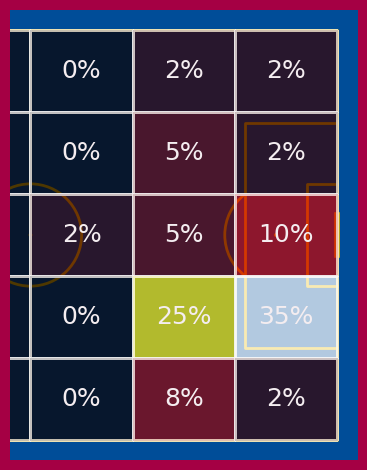

In [24]:
dangerPass(sPIY)

#### Assists

In [25]:
iyAssists = initialYears[initialYears['pass_goal_assist']==True]

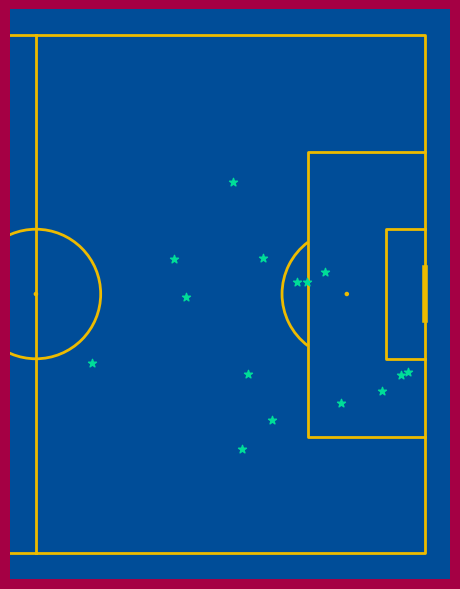

In [26]:
scatter(iyAssists,"assists")

In [27]:
iyGAssisted = iyAssists['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts')

In [28]:
iyGAssisted.head(5)

,player_name,counts
0,Samuel Eto''o Fils,6
1,Thierry Henry,3
2,Giovani dos Santos Ramírez,2
3,Carles Puyol i Saforcada,1
4,Bojan Krkíc Pérez,1


In [29]:
iySPAssists = iyAssists[iyAssists['pass_type'].isin(setpiece)]

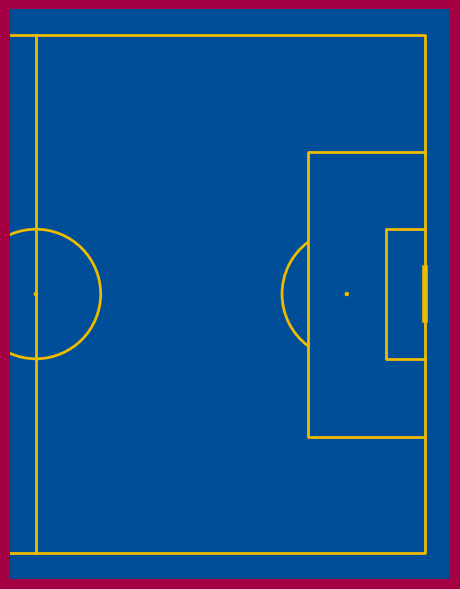

In [30]:
scatter(iySPAssists,"assists")

### Goal Scoring

In [31]:
iyGoals = initialYears[initialYears['shot_outcome']=='Goal']

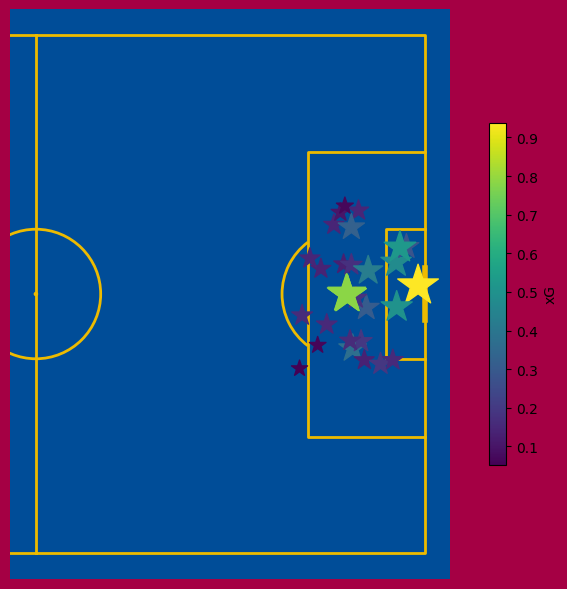

In [32]:
scatter(iyGoals,"goals")

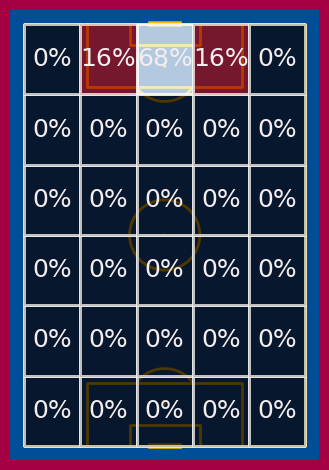

In [33]:
heatmap(iyGoals,"goal")

In [34]:
iySPGoal = iyGoals[iyGoals['shot_type'].isin(setpiece)]

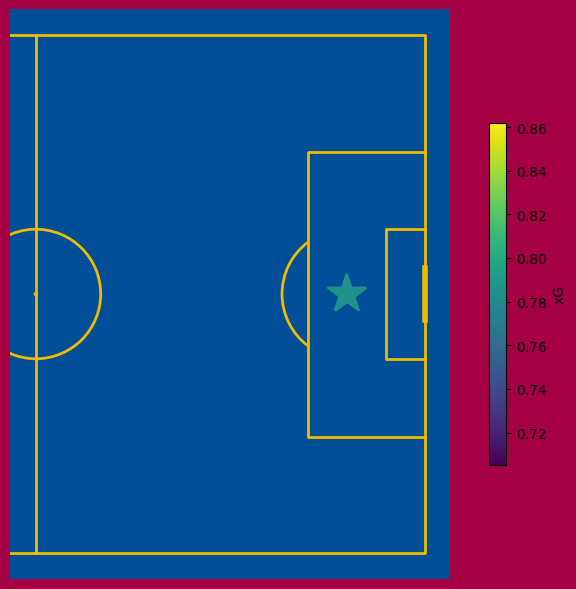

In [35]:
scatter(iySPGoal,"goals")

## European Dominance

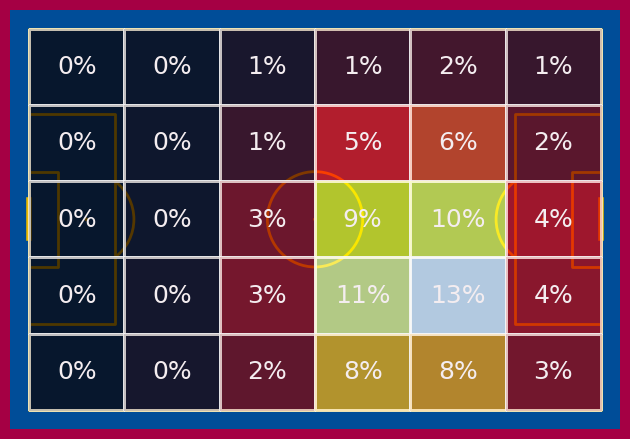

In [36]:
heatmap(pepYears,"all")

### Movement

In [37]:
pyCarry = pepYears[pepYears['type']=='Carry']

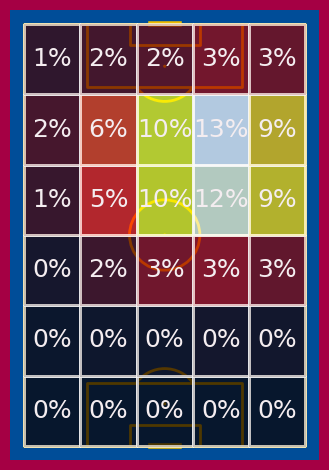

In [38]:
heatmap(pyCarry,"carryStart")

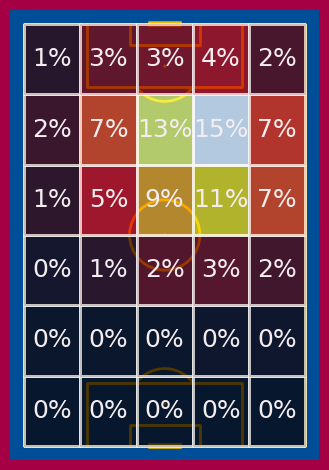

In [39]:
heatmap(pyCarry,"carryEnd")

In [40]:
pyDribbles = pepYears[pepYears['type']=="Dribble"]
pyASDribbles = pyDribbles[pyDribbles['dribble_outcome']=='Complete']
pyNDribbles = pyASDribbles[pyASDribbles['dribble_nutmeg']==True]
pySDribbles = pyASDribbles[pyASDribbles['dribble_nutmeg'].isna()]
pyUDribbles = pyDribbles[pyDribbles['dribble_outcome']=='Incomplete']

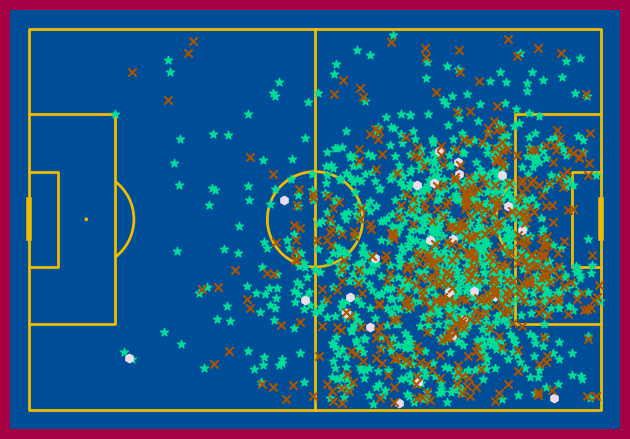

In [41]:
drib(pySDribbles,pyNDribbles,pyUDribbles)

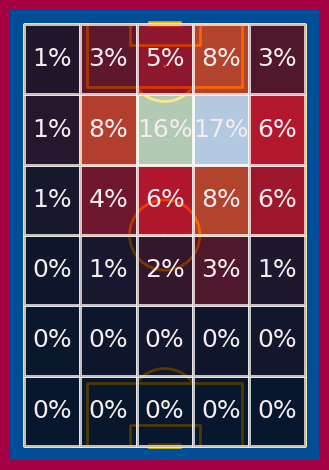

In [42]:
heatmap(pyASDribbles,"dribble")

### Passing

In [43]:
passesPY = pepYears[pepYears['type']=='Pass']
sPPY = passesPY[passesPY['pass_outcome'].isna()]

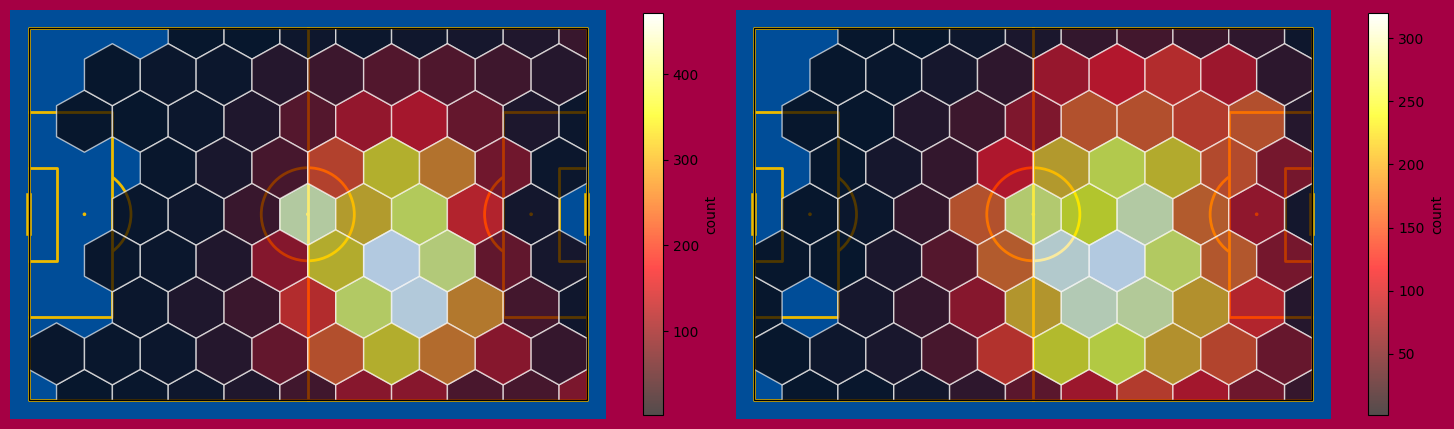

In [44]:
hexbin(sPPY)

In [45]:
topRecip = sPPY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)
topRecip

,player_name,counts
0,Xavier Hernández Creus,1640
1,Daniel Alves da Silva,1360
2,Andrés Iniesta Luján,1076
3,Sergio Busquets i Burgos,653
4,Francesc Fàbregas i Soler,406


### Playmaking

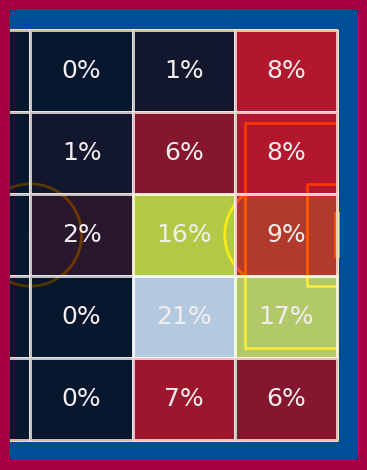

In [46]:
dangerPass(sPPY)

#### Assists

In [47]:
pyAssists = pepYears[pepYears['pass_goal_assist']==True]

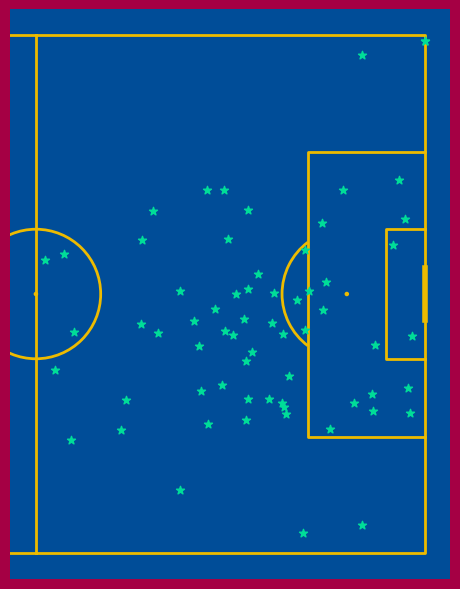

In [48]:
scatter(pyAssists,"assists")

In [49]:
pyGAssisted = pyAssists['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)

In [50]:
pyGAssisted

,player_name,counts
0,David Villa Sánchez,10
1,Pedro Eliezer Rodríguez Ledesma,9
2,Samuel Eto''o Fils,6
3,Francesc Fàbregas i Soler,5
4,Thiago Alcântara do Nascimento,4


In [51]:
pySPAssists = pyAssists[pyAssists['pass_type'].isin(setpiece)]

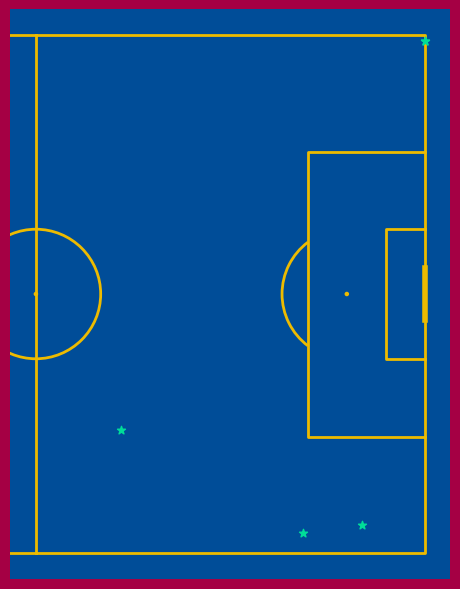

In [52]:
scatter(pySPAssists,"assists")

### Goal Scoring

In [53]:
pyGoals = pepYears[pepYears['shot_outcome']=='Goal']

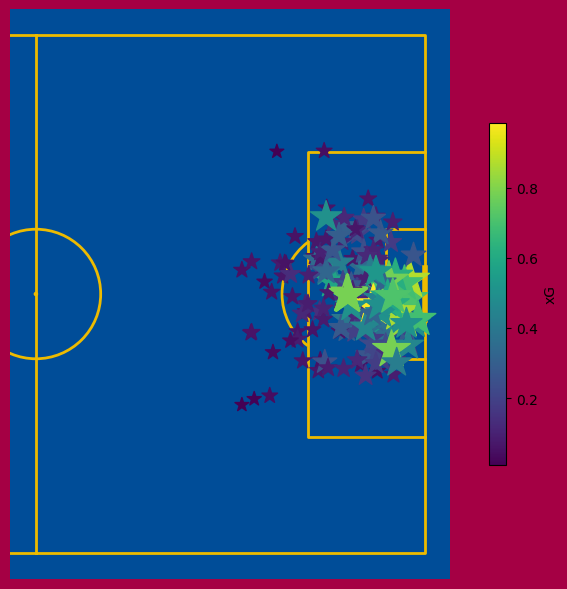

In [54]:
scatter(pyGoals,"goals")

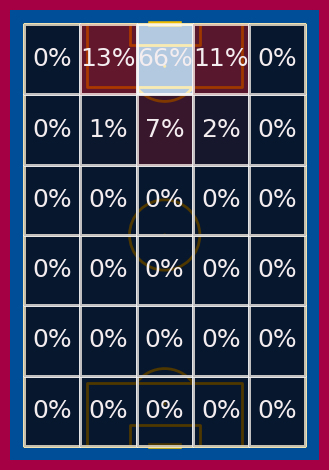

In [55]:
heatmap(pyGoals,"goal")

In [56]:
pySPGoal = pyGoals[pyGoals['shot_type'].isin(setpiece)]

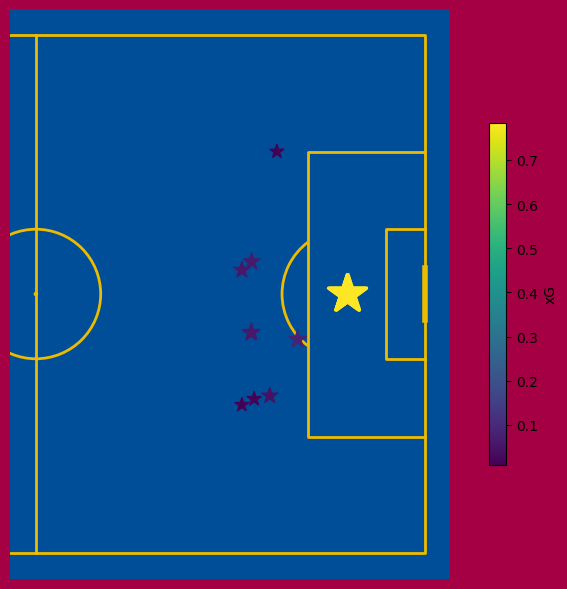

In [57]:
scatter(pySPGoal,"goals")

## Greatest Front Three

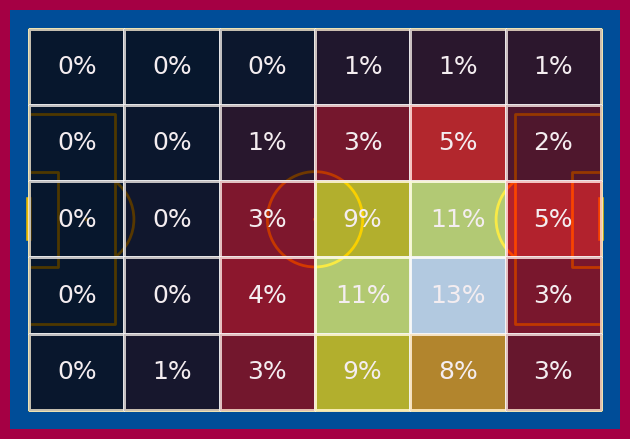

In [58]:
heatmap(msnYears,"all")

### Movement

In [59]:
myCarry = msnYears[msnYears['type']=='Carry']

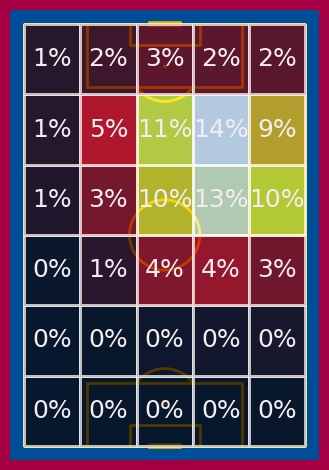

In [60]:
heatmap(myCarry,"carryStart")

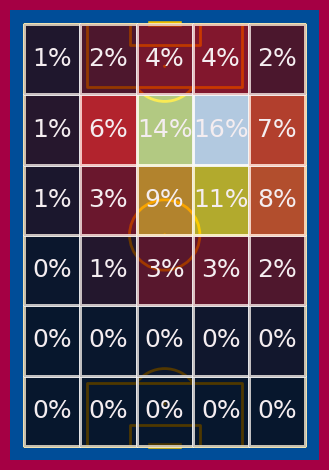

In [61]:
heatmap(myCarry,"carryEnd")

In [62]:
myDribbles = msnYears[msnYears['type']=="Dribble"]
myASDribbles = myDribbles[myDribbles['dribble_outcome']=='Complete']
myNDribbles = myASDribbles[myASDribbles['dribble_nutmeg']==True]
mySDribbles = myASDribbles[myASDribbles['dribble_nutmeg'].isna()]
myUDribbles = myDribbles[myDribbles['dribble_outcome']=='Incomplete']

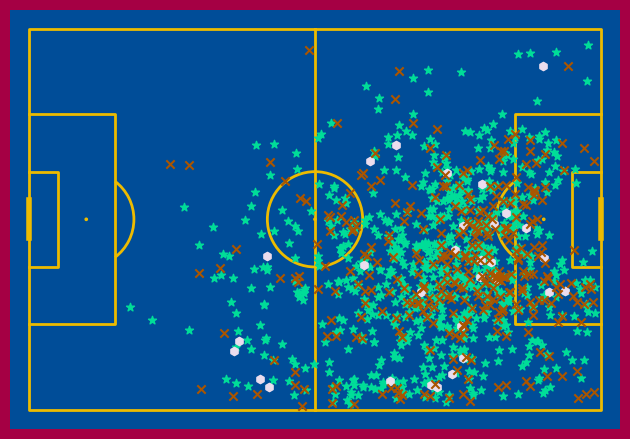

In [63]:
drib(mySDribbles,myNDribbles,myUDribbles)

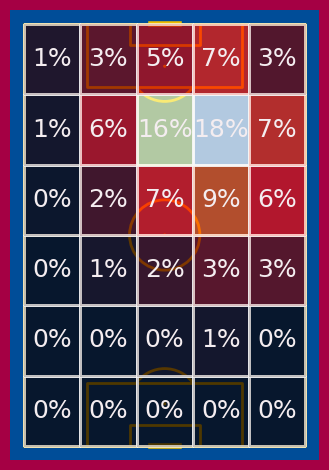

In [64]:
heatmap(myASDribbles,"dribble")

### Passing

In [65]:
passesMY = msnYears[msnYears['type']=='Pass']
sPMY = passesMY[passesMY['pass_outcome'].isna()]

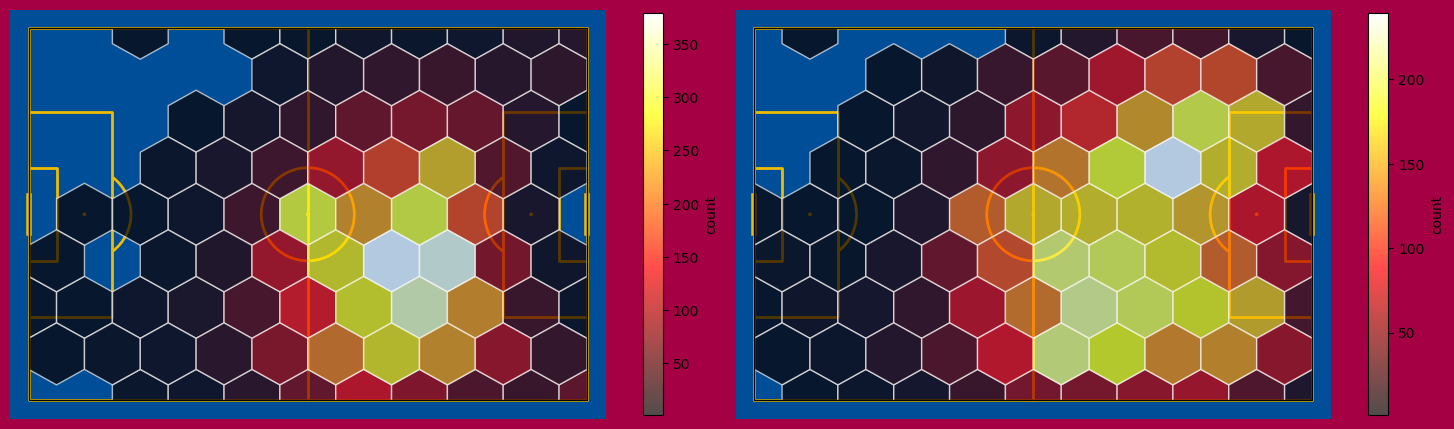

In [66]:
hexbin(sPMY)

In [67]:
topRecip = sPMY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)
topRecip

,player_name,counts
0,Daniel Alves da Silva,695
1,Neymar da Silva Santos Junior,688
2,Sergio Busquets i Burgos,628
3,Andrés Iniesta Luján,595
4,Ivan Rakitić,506


### Playmaking

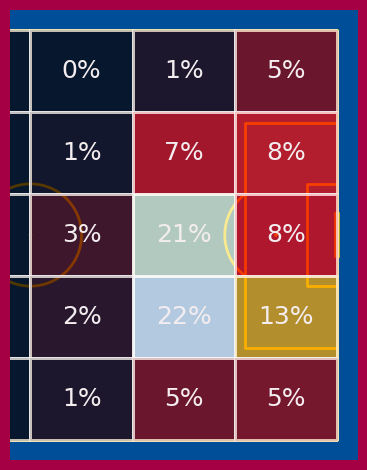

In [68]:
dangerPass(sPMY)

#### Assists

In [69]:
myAssists = msnYears[msnYears['pass_goal_assist']==True]

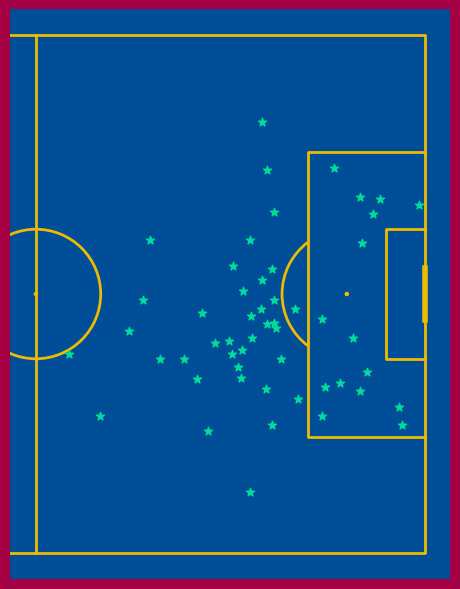

In [70]:
scatter(myAssists,"assists")

In [71]:
myGAssisted = myAssists['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)

In [72]:
myGAssisted

,player_name,counts
0,Luis Alberto Suárez Díaz,16
1,Neymar da Silva Santos Junior,12
2,Ivan Rakitić,5
3,Pedro Eliezer Rodríguez Ledesma,4
4,Alexis Alejandro Sánchez Sánchez,4


In [73]:
mySPAssists = myAssists[myAssists['pass_type'].isin(setpiece)]

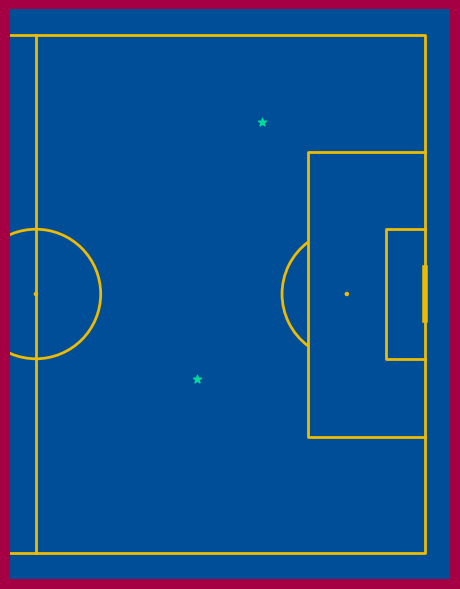

In [74]:
scatter(mySPAssists,"assists")

### Goal Scoring

In [75]:
myGoals = msnYears[msnYears['shot_outcome']=='Goal']

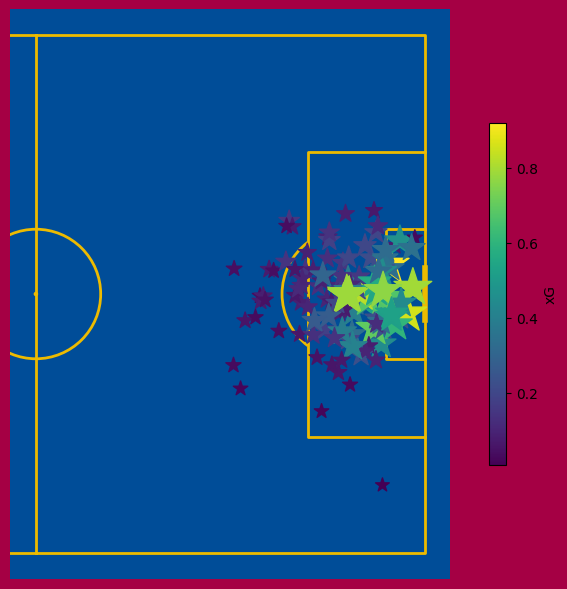

In [76]:
scatter(myGoals,"goals")

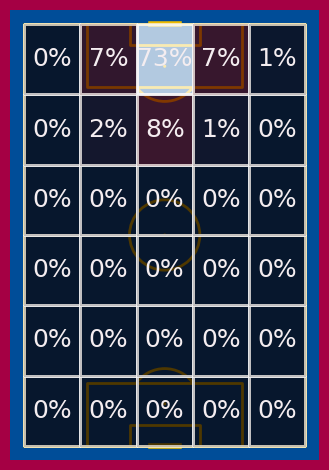

In [77]:
heatmap(myGoals,"goal")

In [78]:
mySPGoal = myGoals[myGoals['shot_type'].isin(setpiece)]

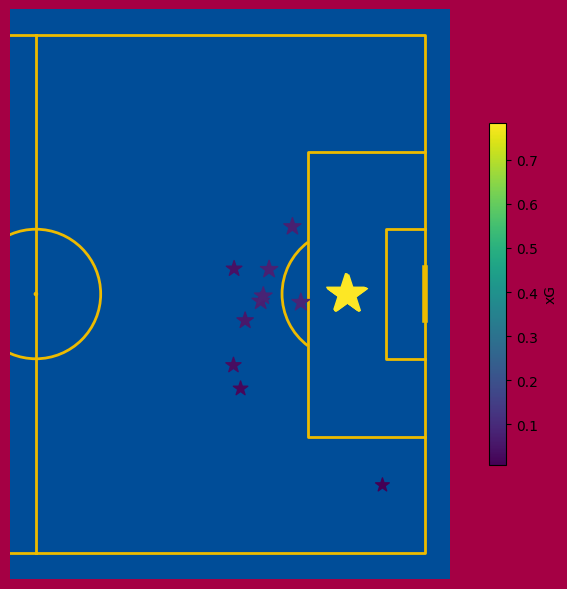

In [79]:
scatter(mySPGoal,"goals")

## Swan Song

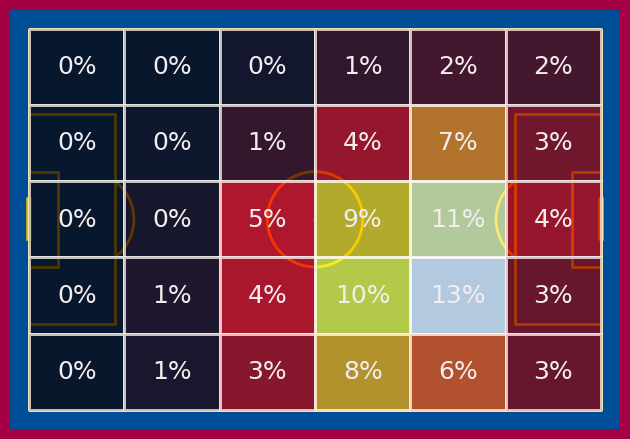

In [80]:
heatmap(swanSong,"all")

### Movement

In [81]:
syCarry = swanSong[swanSong['type']=='Carry']

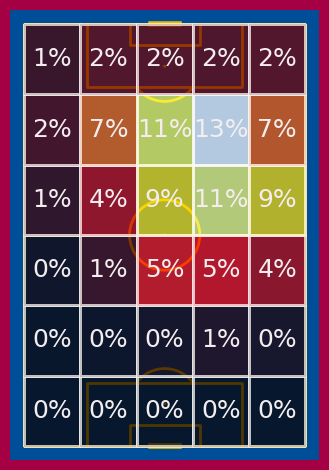

In [82]:
heatmap(syCarry,"carryStart")

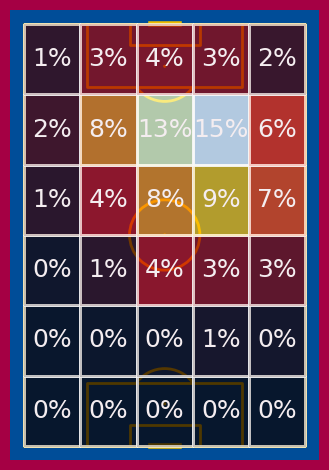

In [83]:
heatmap(syCarry,"carryEnd")

In [84]:
syDribbles = swanSong[swanSong['type']=="Dribble"]
syASDribbles = syDribbles[syDribbles['dribble_outcome']=='Complete']
syNDribbles = syASDribbles[syASDribbles['dribble_nutmeg']==True]
sySDribbles = syASDribbles[syASDribbles['dribble_nutmeg'].isna()]
syUDribbles = syDribbles[syDribbles['dribble_outcome']=='Incomplete']

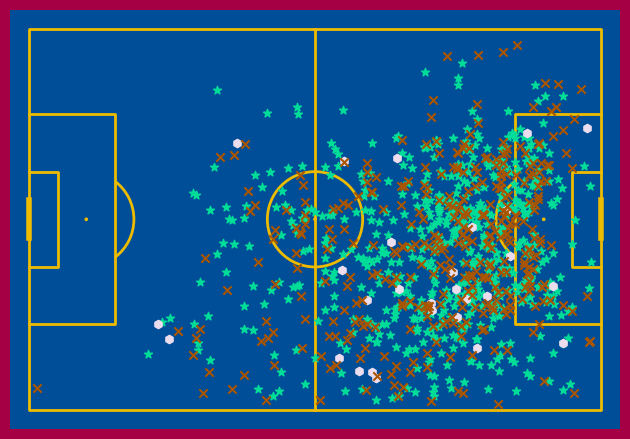

In [85]:
drib(sySDribbles,syNDribbles,syUDribbles)

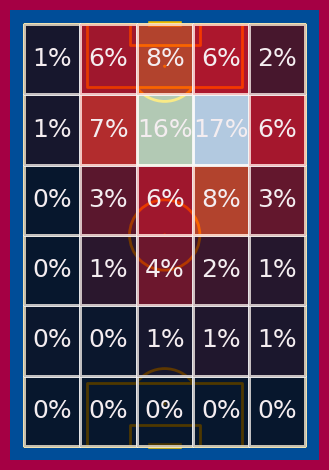

In [86]:
heatmap(syASDribbles,"dribble")

### Passing

In [87]:
passesSY = swanSong[swanSong['type']=='Pass']
sPSY = passesSY[passesSY['pass_outcome'].isna()]

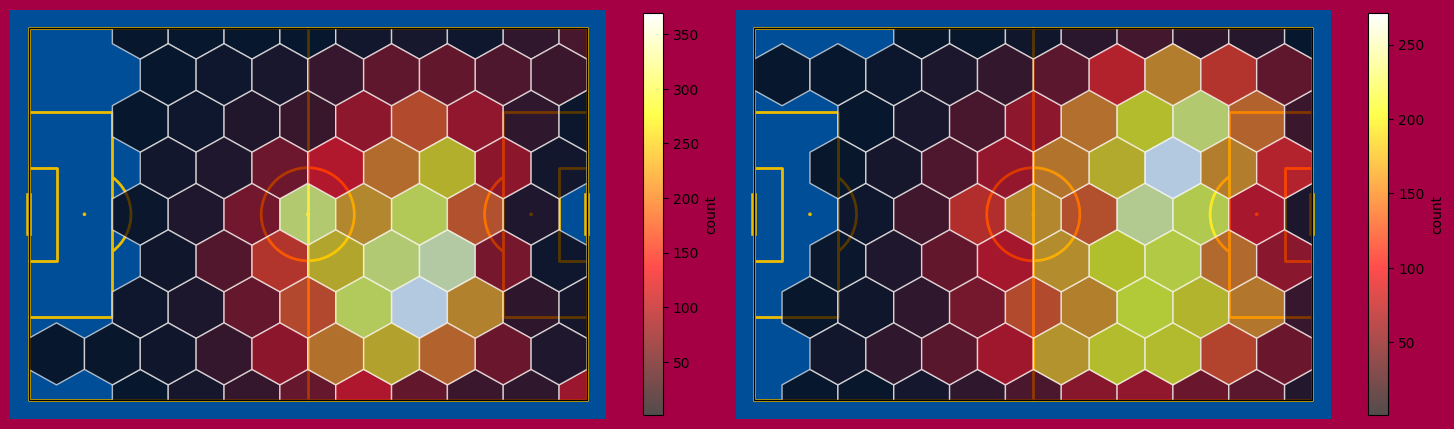

In [88]:
hexbin(sPSY)

In [89]:
topRecip = sPSY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)
topRecip

,player_name,counts
0,Sergio Busquets i Burgos,728
1,Sergi Roberto Carnicer,584
2,Jordi Alba Ramos,578
3,Ivan Rakitić,536
4,Luis Alberto Suárez Díaz,441


### Playmaking

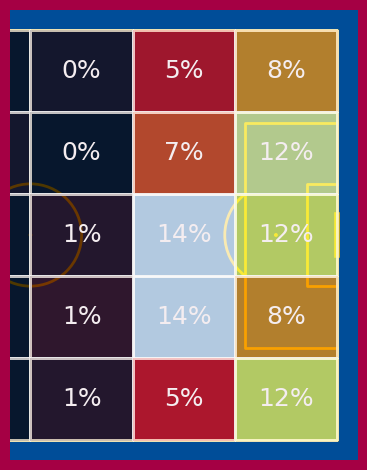

In [90]:
dangerPass(sPSY)

#### Assists

In [91]:
syAssists = swanSong[swanSong['pass_goal_assist']==True]

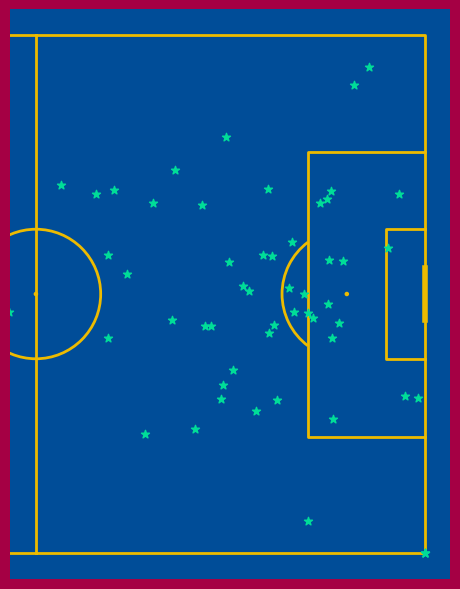

In [92]:
scatter(syAssists,"assists")

In [93]:
syGAssisted = syAssists['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)

In [94]:
syGAssisted

,player_name,counts
0,Luis Alberto Suárez Díaz,14
1,Jordi Alba Ramos,5
2,Antoine Griezmann,4
3,Gerard Piqué Bernabéu,3
4,Ousmane Dembélé,3


In [95]:
sySPAssists = syAssists[syAssists['pass_type'].isin(setpiece)]

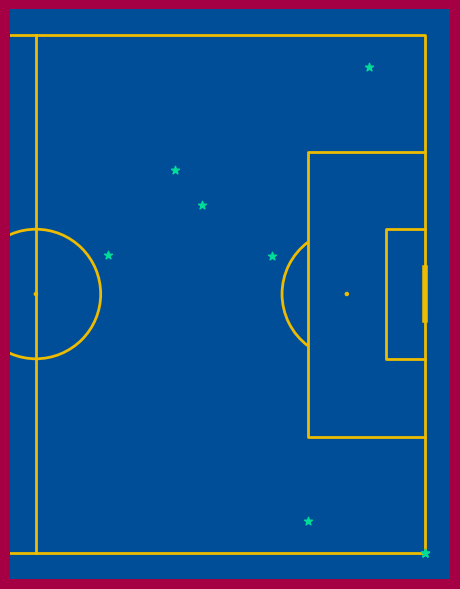

In [96]:
scatter(sySPAssists,"assists")

### Goal Scoring

In [97]:
syGoals = swanSong[swanSong['shot_outcome']=='Goal']

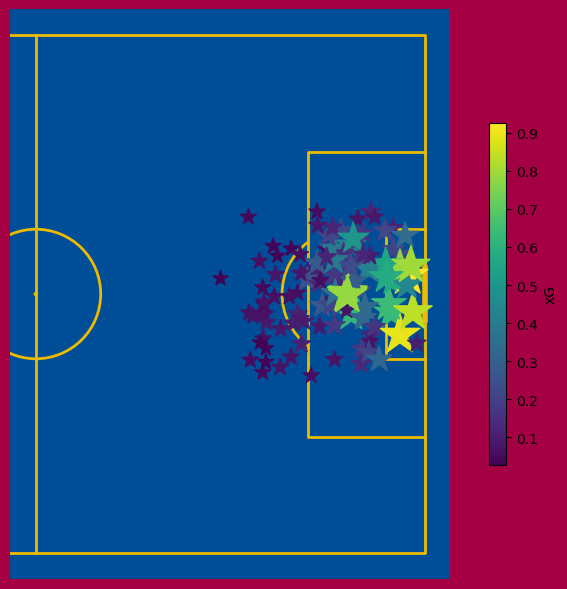

In [98]:
scatter(syGoals,"goals")

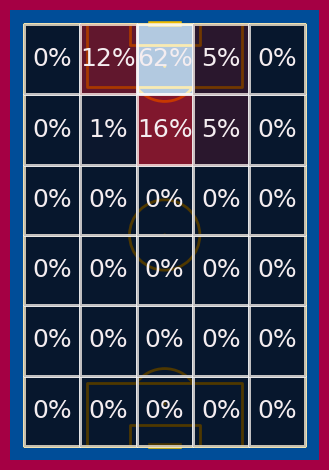

In [99]:
heatmap(syGoals,"goal")

In [100]:
sySPGoal = syGoals[syGoals['shot_type'].isin(setpiece)]

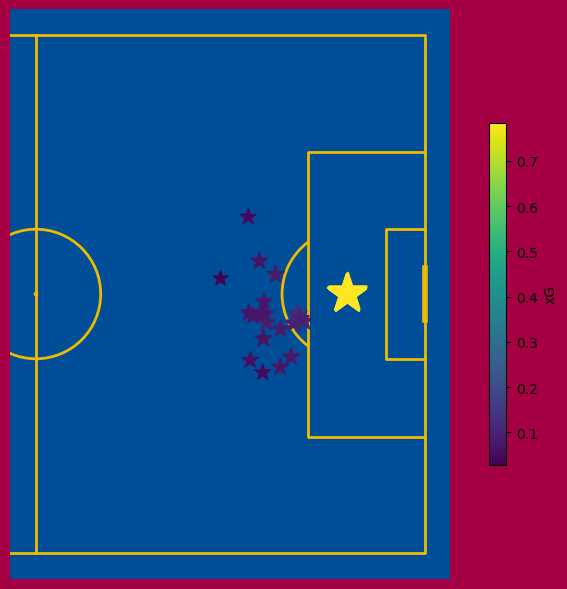

In [101]:
scatter(sySPGoal,"goals")